# Inverse PINN for simultaneous identification of displacement and body force

The goal is to identify both the displacement $u(x)$ and the unknown body-force function $b(x)$ of a one-dimensional elastic bar on

$$
\Omega=(0,1).
$$

Young's modulus is known and constant. For a synthetic inverse experiment, the exact displacement is

$$
u_{\mathrm{exact}}(x)=a\sin(2\pi x),
\qquad
0<a<\frac{1}{2\pi}.
$$

The strain and stress are

$$
\varepsilon(x)=u'(x),
\qquad
\sigma(x)=E u'(x),
$$

and equilibrium requires

$$
E u''(x)+b(x)=0.
$$

The hidden exact body force is

$$
b_{\mathrm{exact}}(x)
=4\pi^2Ea\sin(2\pi x).
$$

 The PINN learns $u_\theta(x)$ and $b_\theta(x)$ as two outputs of one shared network from the equilibrium equation and sparse displacement observations.

## 1. Library imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_default_dtype(torch.float64)

/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Parameters

Set `USE_NOISY_DATA = False` to use exact sparse observations. Set it to `True` to add independent zero-mean Gaussian measurement noise:

$$
u_i^{\mathrm{obs}}
=u_{\mathrm{exact}}(x_i)+\eta_i,
\qquad
\eta_i\sim\mathcal N(0,s_{\mathrm{noise}}^2).
$$

The first-derivative regularizer penalizes spatial variation of the identified body force.

In [2]:
USE_NOISY_DATA = True
NOISE_RELATIVE_STD = 0.02

L = 1.0
E_KNOWN = 1.0
AMPLITUDE = 0.05

N_PDE_TRAIN = 1000
N_PDE_TEST = 1000
PDE_BATCH_SIZE = 16
N_REGULARIZATION = 200
N_DATA_TOTAL = 26
TRAIN_FRACTION = 0.80
N_DATA_TRAIN = int(TRAIN_FRACTION * N_DATA_TOTAL)
N_DATA_TEST = N_DATA_TOTAL - N_DATA_TRAIN

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

WEIGHT_PDE = 1.0
WEIGHT_DATA = 1000.0
WEIGHT_REGULARIZATION = 1e-9

NOISE_STD = NOISE_RELATIVE_STD * AMPLITUDE

torch.manual_seed(SEED)

## 3. Exact fields for synthetic data and evaluation

In [ ]:
def exact_solution(x):
    '''Exact displacement used to generate synthetic observations.'''
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)


def exact_strain(x):
    '''Exact strain u'(x).'''
    return 2.0 * torch.pi * AMPLITUDE * torch.cos(2.0 * torch.pi * x)


def exact_stress(x):
    '''Exact stress for the known Young modulus.'''
    return E_KNOWN * exact_strain(x)


def exact_body_force(x):
    '''Hidden reference body force used only for evaluation.'''
    return (4.0 * torch.pi**2 * E_KNOWN * AMPLITUDE * torch.sin(2.0 * torch.pi * x))

## 4. One neural network for displacement and body force

One shared neural network with two outputs approximates

$$
u(x)\approx u_\theta(x),
\qquad
b(x)\approx b_\theta(x).
$$

The output vector is $[u_\theta(x),b_\theta(x)]^\mathsf{T}$.

In [4]:
class InverseBodyForcePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 30),
            nn.Tanh(),
            nn.Linear(30, 2),
        )

    def forward(self, x):
        return self.net(x)

    def displacement(self, x):
        return self.forward(x)[:, 0:1]

    def body_force(self, x):
        return self.forward(x)[:, 1:2]


model = InverseBodyForcePINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)

## 5. Collocation points and PDE batching

Training collocation points are sampled uniformly from $(0,1)$ and divided into shuffled PDE mini-batches.

In [ ]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
x_pde_train = L * torch.rand(N_PDE_TRAIN, 1, generator=pde_train_generator)

pde_dataset = TensorDataset(x_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 2)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator)

pde_test_generator = torch.Generator().manual_seed(SEED + 3)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=pde_test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)

# Midpoints of the rectangles used for the regularization integral.
REGULARIZATION_DX = L / N_REGULARIZATION
x_regularization = (torch.arange(N_REGULARIZATION).view(-1, 1) + 0.5) * REGULARIZATION_DX

## 6. Train/test split of sparse displacement observations

All sparse sensor locations are sampled uniformly in the interior of the bar and randomly split into training and test subsets.

In [ ]:
data_location_generator = torch.Generator().manual_seed(SEED + 4)
x_data_all = torch.linspace(0.0, L, N_DATA_TOTAL).view(-1, 1)

split_generator = torch.Generator().manual_seed(SEED + 5)
permutation = torch.randperm(N_DATA_TOTAL, generator=split_generator)
train_indices = permutation[:N_DATA_TRAIN]
test_indices = permutation[N_DATA_TRAIN:]

u_data_all_clean = exact_solution(x_data_all).detach()
u_data_all_observed = u_data_all_clean.clone()

if USE_NOISY_DATA:
    noise_generator = torch.Generator().manual_seed(SEED + 6)
    measurement_noise = NOISE_STD * torch.randn(u_data_all_observed.shape, generator=noise_generator)
    u_data_all_observed += measurement_noise

x_data_train = x_data_all[train_indices]
u_data_train = u_data_all_observed[train_indices]
u_data_train_clean = u_data_all_clean[train_indices]

x_data_test = x_data_all[test_indices]
u_data_test = u_data_all_observed[test_indices]
u_data_test_clean = u_data_all_clean[test_indices]

print(
    f'Sparse data split: {N_DATA_TRAIN} train, '
    f'{N_DATA_TEST} test'
)

Sparse data split: 20 train, 6 test


## 7. PDE residual, body-force regularization, and inverse loss

The equilibrium residual is

$$
r_{\mathrm{PDE},\theta}(x)
=E u_\theta''(x)+b_\theta(x).
$$

To prefer a slowly varying body-force reconstruction, we use the integral of the squared first derivative. It is approximated by the midpoint rectangle rule:

$$
\mathcal L_{\mathrm{reg}}
=\int_0^1\left|b_\theta'(x)\right|^2\,\mathrm{d}x
\approx h\sum_{k=1}^{N_{\mathrm{reg}}}
\left|b_\theta'(x_{\mathrm{reg},k})\right|^2,
\qquad h=\frac{1}{N_{\mathrm{reg}}},
\qquad x_{\mathrm{reg},k}=\left(k-\frac12\right)h.
$$

The complete training loss is

$$
\mathcal L
=w_{\mathrm{PDE}}\mathcal L_{\mathrm{PDE}}
+w_{\mathrm{data}}\mathcal L_{\mathrm{data}}
+w_{\mathrm{reg}}\mathcal L_{\mathrm{reg}}.
$$

In [ ]:
def pde_residual(x, training=True):
    x = x.detach().clone().requires_grad_(True)

    fields = model(x)
    u = fields[:, 0:1]
    b = fields[:, 1:2]

    du_dx = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    d2u_dx2 = torch.autograd.grad(du_dx, x, grad_outputs=torch.ones_like(du_dx), create_graph=training, retain_graph=True)[0]

    residual = E_KNOWN * d2u_dx2 + b
    return residual


def body_force_derivative(x, training=True):
    x = x.detach().clone().requires_grad_(True)
    b = model(x)[:, 1:2]
    return torch.autograd.grad(b, x, grad_outputs=torch.ones_like(b), create_graph=training)[0]


def compute_losses(x_pde):
    residual = pde_residual(x_pde, training=True)
    loss_pde = torch.mean(residual**2)

    body_force_gradient = body_force_derivative(x_regularization, training=True)
    loss_regularization = (REGULARIZATION_DX * torch.sum(body_force_gradient**2))

    u_data_prediction = model(x_data_train)[:, 0:1]
    loss_data = torch.mean((u_data_prediction - u_data_train) ** 2)

    loss = (WEIGHT_PDE * loss_pde + WEIGHT_DATA * loss_data + WEIGHT_REGULARIZATION * loss_regularization)

    return (loss, loss_pde, loss_data, loss_regularization)

## 8. Training with Adam mini-batches and full-batch L-BFGS

In [ ]:
loss_history = []
pde_loss_history = []
data_loss_history = []
regularization_loss_history = []
snapshots = {}

x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS

for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)

    for (x_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()

        losses = compute_losses(x_pde_batch)
        loss = losses[0]
        loss.backward()
        optimizer_adam.step()

        epoch_sums += np.array([value.detach().item() for value in losses])

    epoch_losses = epoch_sums / len(pde_loader)
    loss_value, pde_value, data_value, reg_value = epoch_losses

    loss_history.append(loss_value)
    pde_loss_history.append(pde_value)
    data_loss_history.append(data_value)
    regularization_loss_history.append(reg_value)

    if epoch % 250 == 0:
        print(
            f'Adam | epoch {epoch:5d} | '
            f'loss={loss_value:.6e} | '
            f'PDE={pde_value:.6e} | '
            f'data={data_value:.6e} | '
            f'reg={reg_value:.6e}'
        )
        with torch.no_grad():
            snapshots[epoch] = {
                'u': model.displacement(x_plot).detach().numpy().copy(),
                'b': model.body_force(x_plot).detach().numpy().copy(),
            }

with torch.no_grad():
    snapshots[ADAM_EPOCHS - 1] = {
        'u': model.displacement(x_plot).detach().numpy().copy(),
        'b': model.body_force(x_plot).detach().numpy().copy(),
    }

optimizer_lbfgs = torch.optim.LBFGS( model.parameters(), lr=1.0, max_iter=20, history_size=50, line_search_fn='strong_wolfe')

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _ = compute_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    losses = compute_losses(x_pde_train)
    loss, loss_pde, loss_data, loss_regularization = losses
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    data_loss_history.append(loss_data.detach().item())
    regularization_loss_history.append(
        loss_regularization.detach().item()
    )

    if (
        lbfgs_epoch % 50 == 0
        or lbfgs_epoch == LBFGS_EPOCHS - 1
    ):
        print(
            f'L-BFGS | epoch {epoch:5d} | '
            f'loss={loss.item():.6e} | '
            f'PDE={loss_pde.item():.6e} | '
            f'data={loss_data.item():.6e} | '
            f'reg={loss_regularization.item():.6e}'
        )

with torch.no_grad():
    snapshots[EPOCHS - 1] = {
        'u': model.displacement(x_plot).detach().numpy().copy(),
        'b': model.body_force(x_plot).detach().numpy().copy(),
    }

model.eval()

Adam | epoch     0 | loss=3.199569e+00 | PDE=3.475692e-03 | data=3.196093e-03 | reg=1.473109e-03
Adam | epoch   250 | loss=2.605612e-03 | PDE=4.638329e-05 | data=2.559187e-06 | reg=4.153398e+01
Adam | epoch   500 | loss=1.323926e-03 | PDE=3.161508e-05 | data=1.292260e-06 | reg=5.014290e+01
Adam | epoch   750 | loss=1.126071e-03 | PDE=1.760922e-04 | data=9.499200e-07 | reg=5.898546e+01
Adam | epoch  1000 | loss=7.402725e-04 | PDE=8.033995e-05 | data=6.598551e-07 | reg=7.746992e+01
Adam | epoch  1250 | loss=7.575743e-04 | PDE=1.002390e-04 | data=6.572515e-07 | reg=8.379799e+01
Adam | epoch  1500 | loss=7.972944e-04 | PDE=1.128875e-04 | data=6.843194e-07 | reg=8.756434e+01
Adam | epoch  1750 | loss=6.900425e-04 | PDE=7.214279e-05 | data=6.178093e-07 | reg=9.039817e+01
Switching from Adam to L-BFGS at epoch 1900.
L-BFGS | epoch  1900 | loss=5.803213e-04 | PDE=2.563654e-05 | data=5.545926e-07 | reg=9.212024e+01
L-BFGS | epoch  1950 | loss=5.796625e-04 | PDE=2.593122e-05 | data=5.536390e-07 

InverseBodyForcePINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=30, bias=True)
    (1): Tanh()
    (2): Linear(in_features=30, out_features=30, bias=True)
    (3): Tanh()
    (4): Linear(in_features=30, out_features=30, bias=True)
    (5): Tanh()
    (6): Linear(in_features=30, out_features=2, bias=True)
  )
)

## 9. Evaluation on independent test points

In [ ]:
with torch.no_grad():
    u_sparse_test_prediction = model.displacement(x_data_test)

    u_test_prediction = model.displacement(x_pde_test)
    b_test_prediction = model.body_force(x_pde_test)

    u_test_exact = exact_solution(x_pde_test)
    b_test_exact = exact_body_force(x_pde_test)

    def r2_score(prediction, target):
        ss_res = torch.sum((prediction - target) ** 2)
        ss_tot = torch.sum((target - torch.mean(target)) ** 2)
        return (1.0 - ss_res / ss_tot).item()

    def relative_l2_error(prediction, target):
        return (torch.linalg.vector_norm(prediction - target) / torch.linalg.vector_norm(target)).item()

    r2_u_test = r2_score(u_test_prediction, u_test_exact)
    relative_l2_u_test = relative_l2_error(u_test_prediction, u_test_exact)
    r2_b_test = r2_score(b_test_prediction, b_test_exact)
    relative_l2_b_test = relative_l2_error(b_test_prediction, b_test_exact)
    
metrics = {
    'R2_displacement_test': r2_u_test,
    'relative_L2_displacement_test': relative_l2_u_test,
    'R2_body_force_test': r2_b_test,
    'relative_L2_body_force_test': relative_l2_b_test,
}

print('=' * 72)
print('INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND BODY FORCE')
print('=' * 72)
print(
    f'Data mode:                         '
    f'{"noisy" if USE_NOISY_DATA else "exact"}'
)
print(f'Displacement R2:                   {r2_u_test:.8f}')
print(
    f'Relative L2 displacement error:   '
    f'{relative_l2_u_test: .6e}'
)
print(f'Body-force R2:                     {r2_b_test:.8f}')
print(
    f'Relative L2 body-force error:     '
    f'{relative_l2_b_test: .6e}'
)
metrics

INVERSE 1D PINN TEST RESULTS: DISPLACEMENT AND BODY FORCE
Data mode:                         noisy
Displacement R2:                   0.99957235
Relative L2 displacement error:    2.067583e-02
Body-force R2:                     0.99208096
Relative L2 body-force error:      8.897224e-02
PDE residual MSE:                  2.862336e-05


{'R2_displacement_test': 0.9995723491230377,
 'relative_L2_displacement_test': 0.020675828751920113,
 'R2_body_force_test': 0.992080959863174,
 'relative_L2_body_force_test': 0.08897223802896774,
 'PDE_residual_MSE_test': 2.8623362736763044e-05,
 'sparse_test_MSE_observed': 1.0434293353545441e-06,
 'sparse_test_MSE_clean': 5.77879356792362e-07}

## 10. Visualization functions

In [ ]:
def plot_points_and_data():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(x_pde_train.numpy(), np.ones((len(x_pde_train), 1)),
        s=16, alpha=0.5, label=f'PDE train ({len(x_pde_train)})')
    axes[0].scatter(x_pde_test.numpy(), np.zeros((len(x_pde_test), 1)),
                     s=16, marker='x', alpha=0.5, label=f'PDE test ({len(x_pde_test)})')
    axes[0].set_yticks([0, 1], labels=['test', 'train'])
    axes[0].set(xlabel='x', title='Collocation points')
    axes[0].legend()
    axes[0].grid(axis='x')

    u_plot_exact = exact_solution(x_plot)
    axes[1].plot(x_plot.numpy(), u_plot_exact.numpy(), 'k--', label='Exact displacement')
    axes[1].scatter(x_data_train.numpy(), u_data_train.numpy(),
        color='tab:blue', s=45, label=f'Train measurements ({N_DATA_TRAIN})', zorder=3)
    axes[1].scatter(x_data_test.numpy(), u_data_test.numpy(), color='tab:orange',
        marker='x', s=55, label=f'Test measurements ({N_DATA_TEST})', zorder=3)
    axes[1].set(xlabel='x', ylabel='u(x)',
        title=('Gaussian-noisy sparse data'if USE_NOISY_DATA else 'Exact sparse data'))
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_points_and_data.pdf', bbox_inches='tight')
    plt.show()


def plot_identified_fields():
    with torch.no_grad():
        u_prediction = model.displacement(x_plot)
        b_prediction = model.body_force(x_plot)
        u_exact = exact_solution(x_plot)
        b_exact = exact_body_force(x_plot)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot.numpy(), u_exact.numpy(),'r--', linewidth=2, label='Exact')
    axes[0].plot(x_plot.numpy(), u_prediction.numpy(), linewidth=2, label='Inverse PINN')
    axes[0].scatter(x_data_train.numpy(), u_data_train.numpy(),
        color='black', s=35, label='Train data', zorder=3)
    axes[0].scatter(x_data_test.numpy(), u_data_test.numpy(),
                     color='tab:orange', marker='x', s=50, label='Held-out test data', zorder=3,)
    axes[0].set(xlabel='x', ylabel='u(x)', title='Identified displacement')
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(x_plot.numpy(), b_exact.numpy(), 'r--', linewidth=2, label='Hidden exact')
    axes[1].plot(x_plot.numpy(), b_prediction.numpy(), linewidth=2, label='Inverse PINN')
    axes[1].set(xlabel='x', ylabel='b(x)', title='Identified body force')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_identified_fields.pdf', bbox_inches='tight')
    plt.show()


def plot_losses_and_body_force_history():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, label='weighted total')
    axes[0].plot(pde_loss_history, label='PDE MSE')
    axes[0].plot(data_loss_history, label='train data MSE')
    axes[0].plot(regularization_loss_history, label='first-derivative regularizer')
    axes[0].axvline(ADAM_EPOCHS, color='black', linestyle=':', label='switch to L-BFGS')
    axes[0].set_yscale('log')
    axes[0].set(xlabel='epoch', ylabel='loss', title='Training losses')
    axes[0].legend()
    axes[0].grid()

    b_exact = exact_body_force(x_plot)
    axes[1].plot(x_plot.numpy(), b_exact.numpy(), 'k--', linewidth=2, label='Hidden exact')
    snapshot_epochs = [0, ADAM_EPOCHS - 1, EPOCHS - 1]
    snapshot_styles = [':', '-.', '-']
    snapshot_labels = ['after epoch 0', 'after Adam', 'final']
    for epoch, style, label in zip(snapshot_epochs, snapshot_styles, snapshot_labels,):
        axes[1].plot(x_plot.numpy(), snapshots[epoch]['b'], linestyle=style, label=label)
    axes[1].set(xlabel='x', ylabel='b(x)', title='Body-force identification history')
    axes[1].legend()
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_loss_and_history.pdf', bbox_inches='tight')
    plt.show()


def plot_absolute_errors():
    with torch.no_grad():
        absolute_u_error = torch.abs(model.displacement(x_plot) - exact_solution(x_plot))
        absolute_b_error = torch.abs(model.body_force(x_plot) - exact_body_force(x_plot))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(x_plot.numpy(), absolute_u_error.numpy())
    axes[0].set(xlabel='x', ylabel='absolute error', title='Absolute displacement error')
    axes[0].grid()

    axes[1].plot(x_plot.numpy(), absolute_b_error.numpy())
    axes[1].set(xlabel='x', ylabel='absolute error', title='Absolute body-force error')
    axes[1].grid()

    fig.tight_layout()
    plt.savefig('pinn_inverse_b_absolute_errors.pdf', bbox_inches='tight')
    plt.show()


In [ ]:
def plot_body_force_l2_error_heatmap(n=400):
    x_heatmap = torch.linspace(0.0, L, n).view(-1, 1)

    with torch.no_grad():
        b_prediction = model.body_force(x_heatmap)
        b_exact = exact_body_force(x_heatmap)

        squared_error = (b_prediction - b_exact) ** 2
        exact_squared_norm = torch.sum(b_exact ** 2)

        
        l2_contribution = squared_error / exact_squared_norm

       
        relative_l2_error = torch.sqrt(torch.sum(l2_contribution)).item()

    heatmap = l2_contribution.numpy().reshape(1, -1)

    fig, ax = plt.subplots(figsize=(10, 2.5))

    image = ax.imshow(heatmap, extent=(0.0, L, 0.0, 1.0), origin="lower", aspect="auto", cmap="magma")

    ax.set_xlabel("x")
    ax.set_yticks([])
    ax.set_title("Relative L2 body-force error\n")

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(r"$(b_\theta-b_{\mathrm{exact}})^2/"r"\sum b_{\mathrm{exact}}^2$")

    fig.tight_layout()

    plt.savefig("pinn_inverse_b_l2_error_heatmap.pdf", bbox_inches="tight")

    plt.show()

## 11. Visualizations

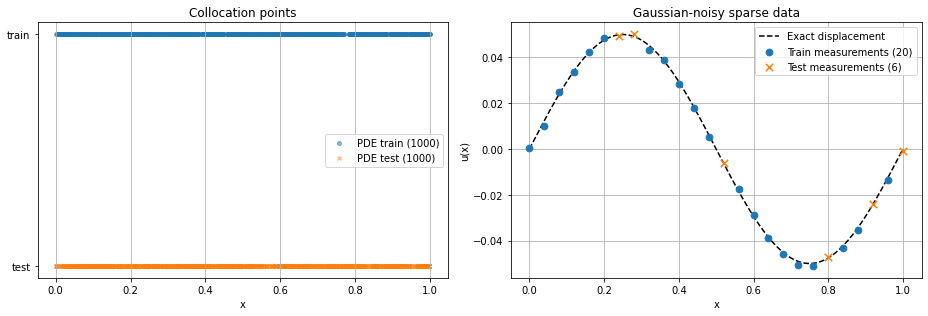

In [12]:
plot_points_and_data()

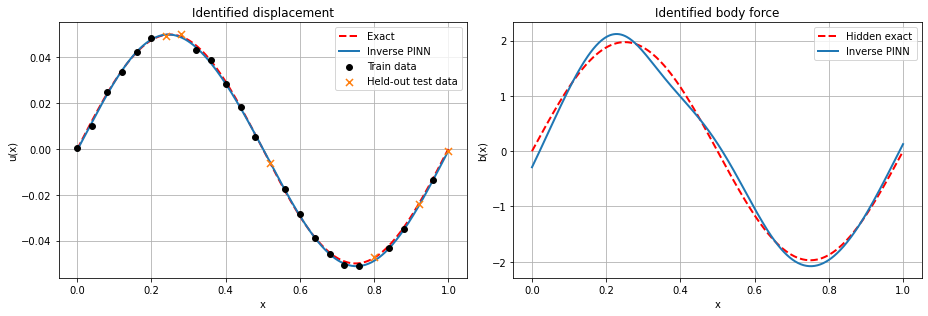

In [13]:
plot_identified_fields()

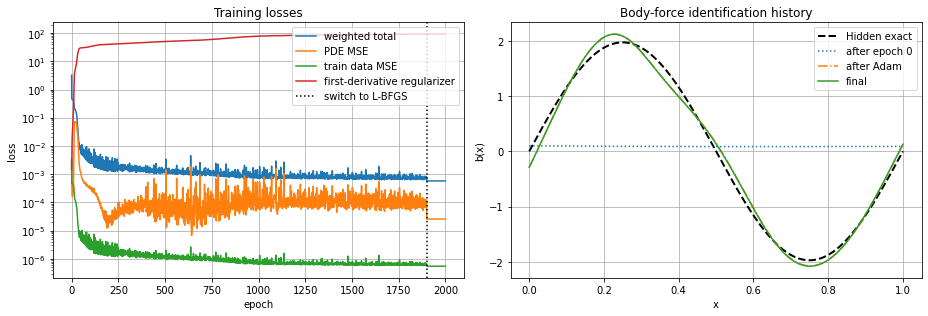

In [14]:
plot_losses_and_body_force_history()

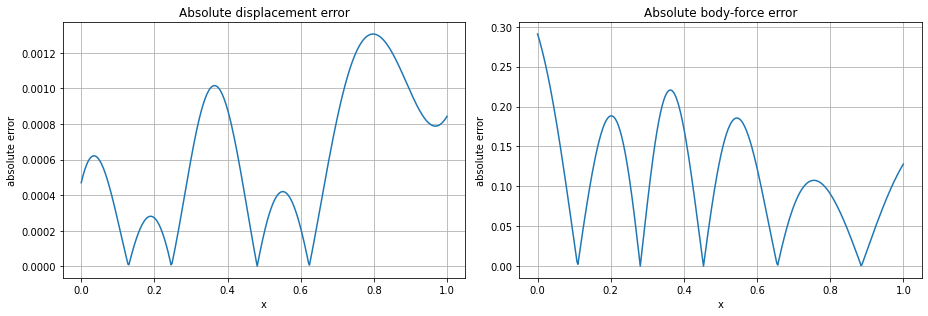

In [15]:
plot_absolute_errors()

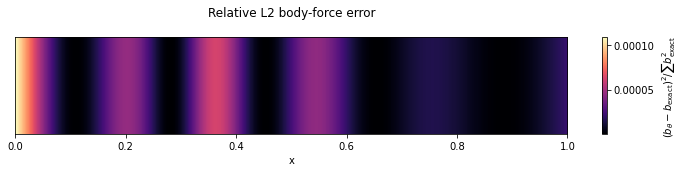

In [16]:
plot_body_force_l2_error_heatmap()